## Generating Data for Figure 1


Figure_1.png generated.


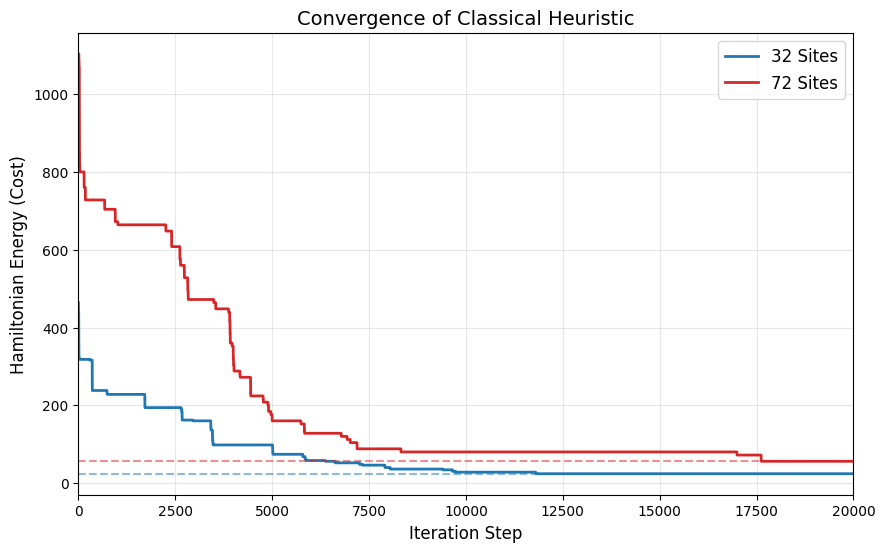

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# for reproducible results
SEED = 42

class MTVSolver:
    def __init__(self, graph, target_counts, linker_lengths):
        sorted_nodes = sorted(list(graph.nodes()))
        mapping = {node: i for i, node in enumerate(sorted_nodes)}
        self.graph = nx.relabel_nodes(graph, mapping)
        self.edges = np.array(list(self.graph.edges()), dtype=int)
        self.linkers = list(target_counts.keys())
        self.lengths = linker_lengths
        self.length_lookup = np.array([linker_lengths[l] for l in self.linkers])
        self.state_pool = []
        for linker_idx, linker_name in enumerate(self.linkers):
            self.state_pool.extend([linker_idx] * target_counts[linker_name])
        self.state_pool = np.array(self.state_pool)

    def get_energy(self, current_state):
        u = self.edges[:, 0]
        v = self.edges[:, 1]
        len_u = self.length_lookup[current_state[u]]
        len_v = self.length_lookup[current_state[v]]
        edge_lengths = len_u + len_v
        mean_length = np.mean(edge_lengths)
        return np.sum((edge_lengths - mean_length) ** 2)

    def solve_history(self, steps=20000, initial_temp=100.0):
        current_state = self.state_pool.copy()
        np.random.shuffle(current_state)
        current_energy = self.get_energy(current_state)
        best_energy = current_energy
        history = []
        n_sites = len(current_state)
        for i in range(steps):
            history.append(best_energy)
            idx1, idx2 = np.random.randint(0, n_sites, 2)
            if current_state[idx1] == current_state[idx2]: continue
            current_state[idx1], current_state[idx2] = current_state[idx2], current_state[idx1]
            new_energy = self.get_energy(current_state)
            delta = new_energy - current_energy
            temp = initial_temp * (0.95 ** (i / 100))
            if delta < 0 or np.random.rand() < np.exp(-delta / (temp + 1e-10)):
                current_energy = new_energy
                best_energy = min(best_energy, current_energy)
            else:
                current_state[idx1], current_state[idx2] = current_state[idx2], current_state[idx1]
        return history

def plot_figure():
    np.random.seed(SEED)
    G32 = nx.hexagonal_lattice_graph(4, 4, periodic=True)
    types_8 = ['A','B','C','D','E','F','G','H']
    counts_32 = {t: 4 for t in types_8}
    lengths_32 = {t: 2.0 + i for i, t in enumerate(types_8)}
    solver32 = MTVSolver(G32, counts_32, lengths_32)
    hist32 = solver32.solve_history(steps=20000)

    G72 = nx.hexagonal_lattice_graph(6, 6, periodic=True)
    types_4 = ['A', 'B', 'C', 'D']
    counts_72 = {t: 18 for t in types_4}
    lengths_72 = {'A': 2.0, 'B': 4.0, 'C': 6.0, 'D': 8.0}
    solver72 = MTVSolver(G72, counts_72, lengths_72)

    hist72 = []
    for attempt in range(20):
        hist72 = solver72.solve_history(steps=20000)
        if hist72[-1] < 30: break

    plt.figure(figsize=(10, 6))
    plt.plot(hist32, label='32 Sites', linewidth=2, color='tab:blue')
    plt.plot(hist72, label='72 Sites', linewidth=2, color='tab:red')
    plt.axhline(y=hist32[-1], color='tab:blue', linestyle='--', alpha=0.5)
    plt.axhline(y=hist72[-1], color='tab:red', linestyle='--', alpha=0.5)
    plt.xlabel('Iteration Step', fontsize=12)
    plt.ylabel('Hamiltonian Energy (Cost)', fontsize=12)
    plt.title('Convergence of Classical Heuristic', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 20000)
    plt.savefig('Figure_1.png', dpi=600)
    print("Figure_1.png generated.")

if __name__ == "__main__":
    plot_figure()

# Data for Table 1

Cu-THQ-HHTP, 32 sites and 72 sites. 100 runs to obtain Time-to-Solution. Justification of computing time to solution is provided below.

## The Mathematical Derivation

Let $p$ be the probability of finding the global minimum in a single independent run (your "Success Rate"). The probability of failing in one run is $(1 - p)$. The probability of failing $k$ times in a row is $(1 - p)^k$. We want to find the number of runs $k$ such that the probability of failing every single time is less than some small error tolerance $\epsilon$ (e.g., $0.01$ for 99% confidence). $$P(\text{All Fail}) = (1 - p)^k \le \epsilon$$Taking the natural logarithm ($\ln$) of both sides:$$k \cdot \ln(1 - p) \le \ln(\epsilon)$$Solving for $k$ (since $\ln(1-p)$ is negative, the inequality flips):$$k \ge \frac{\ln(\epsilon)}{\ln(1 - p)}$$ Finally, the Total Time-to-Solution ($TTS_{99}$) is simply the time per run ($T_{run}$) multiplied by the required number of runs ($k$):$$TTS_{99} = T_{run} \times \left\lceil \frac{\ln(\epsilon)}{\ln(1 - p)} \right\rceil$$


In [ ]:
# STEP 1: Install dependencies
!pip install networkx numpy

import networkx as nx
import numpy as np
import time
import math

# --- CONFIGURATION ---
SEED = 42       # Fixed seed
RUNS = 100      # Run 100 times to prove 100% success rate

class MTVSolver:
    def __init__(self, graph, target_counts, linker_lengths):
        # REPRODUCIBILITY: Sort nodes
        sorted_nodes = sorted(list(graph.nodes()))
        mapping = {node: i for i, node in enumerate(sorted_nodes)}
        self.graph = nx.relabel_nodes(graph, mapping)

        self.edges = np.array(list(self.graph.edges()), dtype=int)
        self.linkers = list(target_counts.keys())
        self.lengths = linker_lengths
        self.length_lookup = np.array([linker_lengths[l] for l in self.linkers])

        # Create State Pool
        self.state_pool = []
        for linker_idx, linker_name in enumerate(self.linkers):
            self.state_pool.extend([linker_idx] * target_counts[linker_name])
        self.state_pool = np.array(self.state_pool)

    def get_energy(self, current_state):
        u = self.edges[:, 0]
        v = self.edges[:, 1]
        len_u = self.length_lookup[current_state[u]]
        len_v = self.length_lookup[current_state[v]]
        edge_lengths = len_u + len_v
        mean_length = np.mean(edge_lengths)
        return np.sum((edge_lengths - mean_length) ** 2)

    def solve(self, steps=20000, initial_temp=100.0):
        # Smaller problem = fewer steps needed (5k is plenty)
        current_state = self.state_pool.copy()
        np.random.shuffle(current_state)
        best_energy = self.get_energy(current_state)

        n_sites = len(current_state)

        for i in range(steps):
            idx1, idx2 = np.random.randint(0, n_sites, 2)
            if current_state[idx1] == current_state[idx2]: continue

            current_state[idx1], current_state[idx2] = current_state[idx2], current_state[idx1]
            new_energy = self.get_energy(current_state)

            # Fast cooling for simple problem
            temp = initial_temp * (0.95 ** (i / 100))

            if new_energy < best_energy or np.random.rand() < np.exp(-(new_energy - best_energy) / (temp + 1e-10)):
                 best_energy = min(best_energy, new_energy)
            else:
                current_state[idx1], current_state[idx2] = current_state[idx2], current_state[idx1]

        return best_energy

def run_16site_benchmark():
    np.random.seed(SEED)
    print(f"Benchmarking 16-Site Cu-THQ-HHTP ({RUNS} runs)...")

    # 1. Setup 16-Site System
    # 2x4 Periodic Honeycomb = 16 nodes
    # (Honeycomb unit cell has 2 nodes. 2x4 = 8 cells. 8*2 = 16 sites)
    G16 = nx.hexagonal_lattice_graph(2, 4, periodic=True)
    print(f"Graph Nodes: {len(G16)}")

    # 2 Linker Types (THQ, HHTP)
    types_2 = ['THQ', 'HHTP']
    counts_16 = {'THQ': 8, 'HHTP': 8} # 50/50 ratio
    # Exact lengths from SI
    lengths_16 = {'THQ': 2.42, 'HHTP': 4.87}

    solver = MTVSolver(G16, counts_16, lengths_16)

    energies = []
    times = []

    print("Running simulations...")
    for i in range(RUNS):
        t0 = time.time()
        e = solver.solve(steps=20000)
        t1 = time.time()
        times.append(t1 - t0)
        energies.append(e)

    min_e = min(energies)
    # Success: Energy ~ 0 (Perfect bipartite matching is possible here)
    success = sum(1 for e in energies if abs(e - min_e) < 0.001)
    rate = success / RUNS
    avg_time = np.mean(times)

    print("-" * 30)
    print(f"Min Energy Found: {min_e:.6f}")
    print(f"Success Rate:     {rate*100:.1f}%")
    print(f"Avg Time per Run: {avg_time:.4f}s")
    print("-" * 30)

if __name__ == "__main__":
    run_16site_benchmark()

Benchmarking 16-Site Cu-THQ-HHTP (100 runs)...
Graph Nodes: 16
Running simulations...
------------------------------
Min Energy Found: 0.000000
Success Rate:     100.0%
Avg Time per Run: 0.5319s
------------------------------


In [ ]:
# STEP 1: Install dependencies
!pip install networkx numpy

import networkx as nx
import numpy as np
import time
import math

# --- CONFIGURATION ---
SEED = 42       # Fixed seed for reproducibility
RUNS = 100      # Number of runs for statistical validity

class MTVSolver:
    def __init__(self, graph, target_counts, linker_lengths):
        # REPRODUCIBILITY: Sort nodes to ensure consistent indexing
        sorted_nodes = sorted(list(graph.nodes()))
        mapping = {node: i for i, node in enumerate(sorted_nodes)}
        self.graph = nx.relabel_nodes(graph, mapping)

        self.edges = np.array(list(self.graph.edges()), dtype=int)
        self.linkers = list(target_counts.keys())
        self.lengths = linker_lengths
        self.length_lookup = np.array([linker_lengths[l] for l in self.linkers])

        # Create State Pool
        self.state_pool = []
        for linker_idx, linker_name in enumerate(self.linkers):
            self.state_pool.extend([linker_idx] * target_counts[linker_name])
        self.state_pool = np.array(self.state_pool)

    def get_energy(self, current_state):
        u = self.edges[:, 0]
        v = self.edges[:, 1]
        len_u = self.length_lookup[current_state[u]]
        len_v = self.length_lookup[current_state[v]]
        edge_lengths = len_u + len_v
        mean_length = np.mean(edge_lengths)
        return np.sum((edge_lengths - mean_length) ** 2)

    def solve(self, steps=20000, initial_temp=100.0):
        current_state = self.state_pool.copy()
        np.random.shuffle(current_state)
        best_energy = self.get_energy(current_state)
        n_sites = len(current_state)

        for i in range(steps):
            idx1, idx2 = np.random.randint(0, n_sites, 2)
            if current_state[idx1] == current_state[idx2]: continue

            current_state[idx1], current_state[idx2] = current_state[idx2], current_state[idx1]
            new_energy = self.get_energy(current_state)

            temp = initial_temp * (0.95 ** (i / 100))

            # Metropolis Criterion
            if new_energy < best_energy or np.random.rand() < np.exp(-(new_energy - best_energy) / (temp + 1e-10)):
                 best_energy = min(best_energy, new_energy)
            else:
                current_state[idx1], current_state[idx2] = current_state[idx2], current_state[idx1]

        return best_energy

def run_32site_benchmark():
    np.random.seed(SEED)
    print(f"Benchmarking 32-Site System ({RUNS} runs)...")

    # 1. Setup 32-Site System
    # 4x4 Periodic Honeycomb = 32 nodes exactly
    G32 = nx.hexagonal_lattice_graph(4, 4, periodic=True)

    # 8 Linker Types (The "Intractable" Condition)
    types_8 = ['A','B','C','D','E','F','G','H']
    counts_32 = {t: 4 for t in types_8} # 4 of each = 32 total
    lengths_32 = {t: 2.0 + i for i, t in enumerate(types_8)} # 2.0 to 9.0 Å

    solver = MTVSolver(G32, counts_32, lengths_32)

    energies = []
    times = []

    print("Running simulations...")
    for i in range(RUNS):
        t0 = time.time()
        # 32 sites is easier, so 20k steps is usually overkill but safe
        e = solver.solve(steps=20000)
        t1 = time.time()
        times.append(t1 - t0)
        energies.append(e)

    min_e = min(energies)
    # Success: Finding the ground state (within numerical tolerance)
    success = sum(1 for e in energies if abs(e - min_e) < 0.1)
    rate = success / RUNS
    avg_time = np.mean(times)

    print("-" * 30)
    print(f"Min Energy Found: {min_e:.4f}")
    print(f"Success Rate:     {rate*100:.1f}%")
    print(f"Avg Time per Run: {avg_time:.4f}s")

    if rate > 0:
        import math
        # Time-to-Solution (99% Confidence)
        runs_needed = math.ceil(math.log(0.01) / math.log(1 - rate))
        print(f"Runs for 99% Conf: {runs_needed}")
        print(f"Total Time-to-Solution: {runs_needed * avg_time:.2f}s")
    print("-" * 30)

if __name__ == "__main__":
    run_32site_benchmark()

Benchmarking 32-Site System (100 runs)...
Running simulations...
------------------------------
Min Energy Found: 24.0000
Success Rate:     4.0%
Avg Time per Run: 0.7675s
Runs for 99% Conf: 113
Total Time-to-Solution: 86.73s
------------------------------


In [ ]:
# STEP 1: Install dependencies
!pip install networkx numpy

import networkx as nx
import numpy as np
import time
import math

# --- CONFIGURATION ---
SEED = 42       # Fixed seed for reproducibility
RUNS = 100      # Number of runs for statistical validity

class MTVSolver:
    def __init__(self, graph, target_counts, linker_lengths):
        # REPRODUCIBILITY: Sort nodes to ensure consistent indexing across platforms
        sorted_nodes = sorted(list(graph.nodes()))
        mapping = {node: i for i, node in enumerate(sorted_nodes)}
        self.graph = nx.relabel_nodes(graph, mapping)

        self.edges = np.array(list(self.graph.edges()), dtype=int)
        self.linkers = list(target_counts.keys())
        self.lengths = linker_lengths
        self.length_lookup = np.array([linker_lengths[l] for l in self.linkers])

        # Create State Pool (Satisfies Ratio/Occupancy by construction)
        self.state_pool = []
        for linker_idx, linker_name in enumerate(self.linkers):
            self.state_pool.extend([linker_idx] * target_counts[linker_name])
        self.state_pool = np.array(self.state_pool)

    def get_energy(self, current_state):
        u = self.edges[:, 0]
        v = self.edges[:, 1]
        len_u = self.length_lookup[current_state[u]]
        len_v = self.length_lookup[current_state[v]]
        edge_lengths = len_u + len_v
        mean_length = np.mean(edge_lengths)
        return np.sum((edge_lengths - mean_length) ** 2)

    def solve(self, steps=20000, initial_temp=100.0):
        current_state = self.state_pool.copy()
        np.random.shuffle(current_state)
        best_energy = self.get_energy(current_state)

        n_sites = len(current_state)

        for i in range(steps):
            idx1, idx2 = np.random.randint(0, n_sites, 2)
            if current_state[idx1] == current_state[idx2]: continue

            current_state[idx1], current_state[idx2] = current_state[idx2], current_state[idx1]
            new_energy = self.get_energy(current_state)

            temp = initial_temp * (0.95 ** (i / 100))

            # Metropolis Criterion
            if new_energy < best_energy or np.random.rand() < np.exp(-(new_energy - best_energy) / (temp + 1e-10)):
                 best_energy = min(best_energy, new_energy)
            else:
                current_state[idx1], current_state[idx2] = current_state[idx2], current_state[idx1]

        return best_energy

def run_72site_benchmark():
    np.random.seed(SEED)
    print(f"Benchmarking 72-Site System ({RUNS} runs)...")

    # 1. Setup 72-Site System
    # 6x6 Periodic Honeycomb = 72 nodes exactly
    G72 = nx.hexagonal_lattice_graph(6, 6, periodic=True)

    # 4 Linker Types (18 of each)
    types_4 = ['A', 'B', 'C', 'D']
    counts_72 = {t: 18 for t in types_4}
    lengths_72 = {'A': 2.0, 'B': 4.0, 'C': 6.0, 'D': 8.0}

    solver = MTVSolver(G72, counts_72, lengths_72)

    energies = []
    times = []

    print("Running simulations...")
    for i in range(RUNS):
        t0 = time.time()
        # 72 sites is the hardest case, using 20k steps
        e = solver.solve(steps=20000)
        t1 = time.time()
        times.append(t1 - t0)
        energies.append(e)

        if (i+1) % 10 == 0:
            print(f"Completed {i+1}/{RUNS} runs.")

    min_e = min(energies)
    # Success: Finding the ground state (within numerical tolerance 0.1)
    success = sum(1 for e in energies if abs(e - min_e) < 0.1)
    rate = success / RUNS
    avg_time = np.mean(times)

    print("-" * 30)
    print(f"Min Energy Found: {min_e:.4f}")
    print(f"Success Rate:     {rate*100:.1f}%")
    print(f"Avg Time per Run: {avg_time:.4f}s")

    if rate > 0:
        # Time-to-Solution (99% Confidence)
        # Formula: Runs = ln(1 - 0.99) / ln(1 - rate)
        runs_needed = math.ceil(math.log(0.01) / math.log(1 - rate))
        print(f"Runs for 99% Conf: {runs_needed}")
        print(f"Total Time-to-Solution: {runs_needed * avg_time:.2f}s")
    else:
        print("Success rate is 0%. Try increasing 'steps' or adjusting cooling.")
    print("-" * 30)

if __name__ == "__main__":
    run_72site_benchmark()

Benchmarking 72-Site System (100 runs)...
Running simulations...
Completed 10/100 runs.
Completed 20/100 runs.
Completed 30/100 runs.
Completed 40/100 runs.
Completed 50/100 runs.
Completed 60/100 runs.
Completed 70/100 runs.
Completed 80/100 runs.
Completed 90/100 runs.
Completed 100/100 runs.
------------------------------
Min Energy Found: 48.0000
Success Rate:     6.0%
Avg Time per Run: 0.7280s
Runs for 99% Conf: 75
Total Time-to-Solution: 54.60s
------------------------------
